In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
df = pd.read_csv("C://Users/User/Downloads/customer_churn.csv")

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [7]:
X = df[['Tenure', 'Total Spend']]
y = df['Churn']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
y_pred = model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.589747572815534

Confusion Matrix:
 [[4389 2404]
 [2878 3204]]

Report:
               precision    recall  f1-score   support

           0       0.60      0.65      0.62      6793
           1       0.57      0.53      0.55      6082

    accuracy                           0.59     12875
   macro avg       0.59      0.59      0.59     12875
weighted avg       0.59      0.59      0.59     12875



In [15]:
probs = model.predict_proba(X_test)

print(probs[:5])

[[0.61095319 0.38904681]
 [0.57059503 0.42940497]
 [0.33289946 0.66710054]
 [0.43719223 0.56280777]
 [0.34269131 0.65730869]]


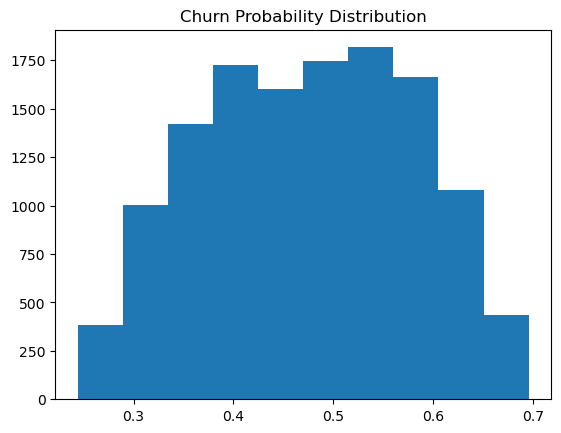

In [16]:
import matplotlib.pyplot as plt

plt.hist(probs[:,1])
plt.title("Churn Probability Distribution")
plt.show()